In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Clean_Text_Youtube - clean_text_youtube (1).csv')
df

,S No.,Link,Upload Date,Views,Likes,Comments,Transcript/Transcript Link,Transcript_Cleaned
0,1,https://youtu.be/Z6LBZoNx9bw?si=P6X0-GY4Quvj84wP,Oct 2025,"2,541",57,11,It's just getting off at like 4:30 in the morn...,working overtime brutal man youre sacrificin...
1,2,https://youtu.be/bmvM_1yzB1g?si=U5h0VjCKZKfhmk9v,February 2026,1711,54,30,"After this 10-hour shift, I couldn't feel my l...",couldnt feel legs straight slavery could use...
2,3,https://youtu.be/MMrH90TzAvo?si=pWwp1Xnex1x6RJjd,Mar 2026,9,0,0,So if you do a job like picking where you hav...,lot walking health know healthier speed things...
3,4,https://youtu.be/OremfN7DCXk?si=G1plTTnjxHk5uhHG,Jan 2025,4128,203,36,number three number three way to learn\nhow to...,literally everything need app youre going go w...
4,5,https://youtu.be/8oKUMyq9Wi0?si=O4R5UWAAMuxeiDlx,Nov 2021,5982,209,64,which i work okay so in our warehouse they rec...,work okay youre trying store fast get store ra...
5,6,https://youtu.be/_H2LuAJEd1M?si=kBaDSmLWOYO95zDE,April 2024,42,5,0,"So, pretty much whatdoing here,this is where a...",simple work know saying describe job pretty m...


In [ ]:
from collections import Counter

all_words = ' '.join(df['Transcript_Cleaned']).split()
word_count = Counter(all_words)

In [ ]:
print(word_count.most_common(5))

[('time', 8), ('youre', 7), ('want', 5), ('know', 5), ('go', 4)]


In [ ]:
word_df = pd.DataFrame(word_count.items(), columns=['word', 'count']).sort_values(by = 'count', ascending = False)
word_df

,word,count
23,time,8
4,youre,7
10,want,5
60,know,5
11,go,4
...,...,...
129,cant,1
130,sit,1
131,gotta,1
132,stand,1


In [ ]:
most_common = word_count.most_common(10)
words, counts = zip(*most_common)

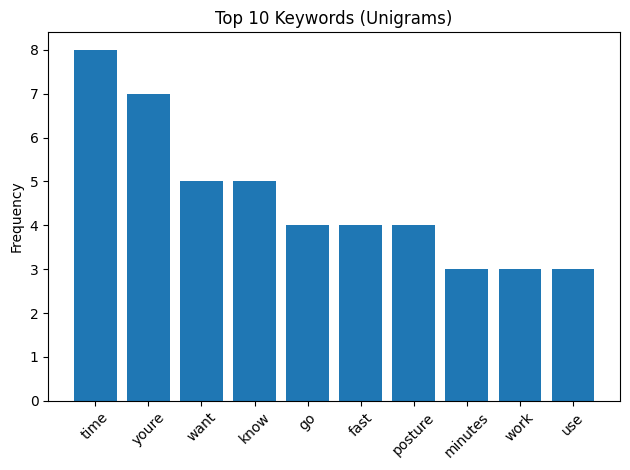

In [ ]:
plt.bar(words, counts)
plt.title("Top 10 Keywords (Unigrams)")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
stop_keywords = ['good', 'work', 'job', 'nice', 'easy', 'take', 'every', 'lot', 'youre', 'know', 'hours', 'got', 'body', 'toz', 'per', 'getting', 'get', 'go', 'app', 'also', 'going', 'want', 'one', 'store', 'much', 'really', 'feel', 'amazon', 'dont', 'want', 'use', 'back', 'working', 'certain', 'minutes', 'trying', 'actually']
filtered_words = [word for word in all_words if word not in stop_keywords]
filtered_counts = Counter(filtered_words)

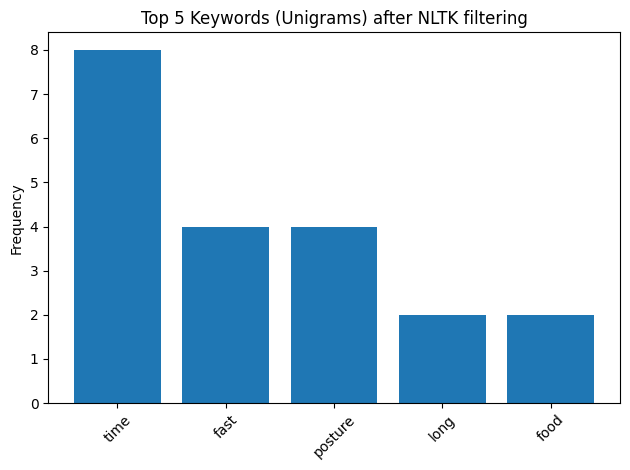

In [ ]:
most_common = filtered_counts.most_common(5)
words, counts = zip(*most_common)

plt.bar(words, counts)
plt.title("Top 5 Keywords (Unigrams) after NLTK filtering")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
from nltk.util import ngrams

stop_keywords = ['good', 'work', '30', 'say', 'job', 'nice', 'easy', 'sounds', 'times', 'specific', 'take', 'see', 'every', 'youre', 'would', 'bags', 'ask', 'know', 'got', 'man', 'body', 'toz', 'per', 'getting', 'get', 'go', 'app', 'also', 'going', 'want', 'one', 'store', 'much', 'really', 'feel', 'amazon', 'dont', 'want', 'use', 'back', 'working', 'minutes', 'trying', 'actually']
filtered_words_for_bigrams = [word for word in all_words if word not in stop_keywords]

bigrams = list(ngrams(filtered_words_for_bigrams, 2))
bigrams_count = Counter(bigrams)

print(bigrams_count.most_common(10))

[(('focus', 'posture'), 2), (('overtime', 'brutal'), 1), (('brutal', 'sacrificing'), 1), (('sacrificing', 'pto'), 1), (('pto', 'departments'), 1), (('departments', 'strict'), 1), (('strict', 'manager'), 1), (('manager', 'long'), 1), (('long', 'time'), 1), (('time', 'try'), 1)]


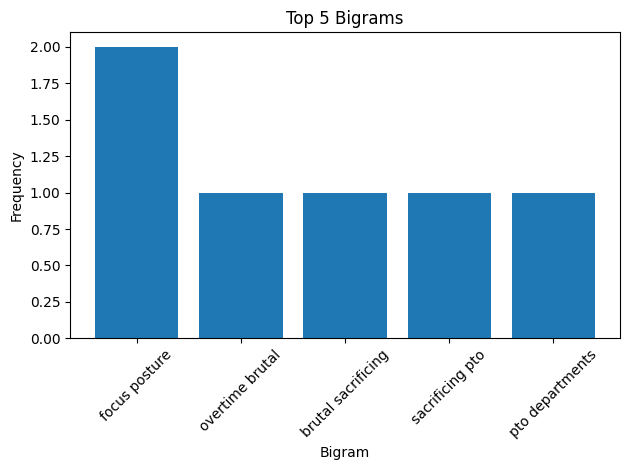

In [ ]:
common_bigrams = bigrams_count.most_common(5)
bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.bar(bg_labels, bg_counts)
plt.title('Top 5 Bigrams')
plt.xlabel('Bigram')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

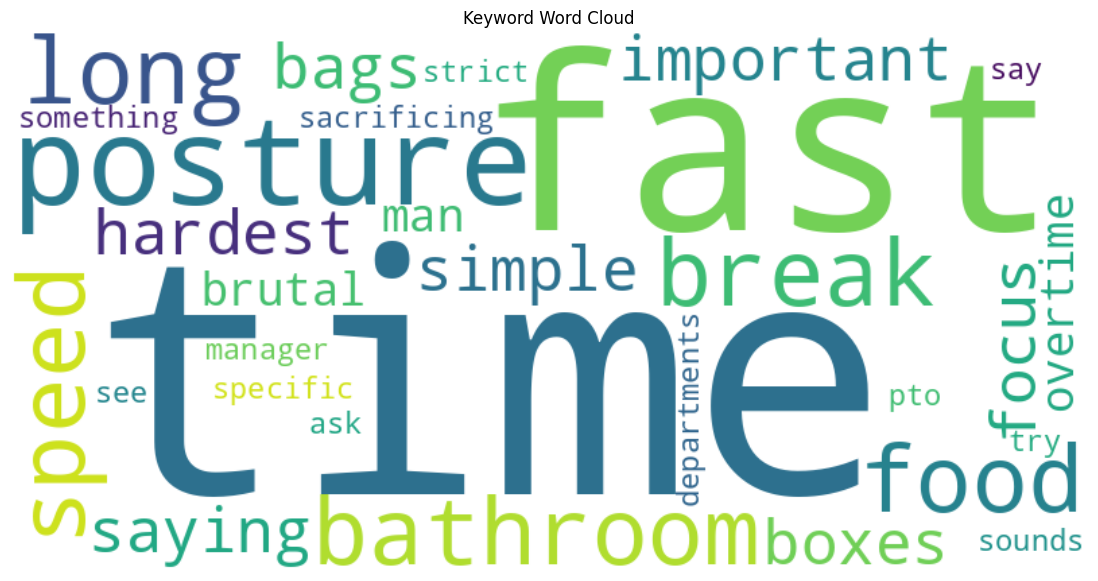

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=30).generate(' '.join(filtered_words))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Keyword Word Cloud")
colormap = 'set3'
plt.show()

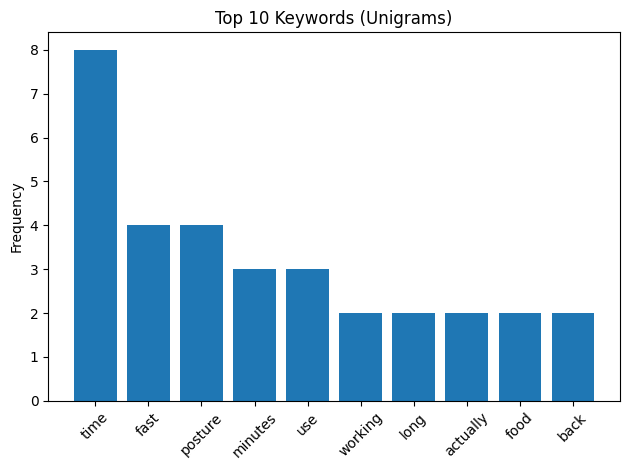

In [ ]:
most_common = filtered_counts.most_common(10)
words, counts = zip(*most_common)

plt.bar(words, counts)
plt.title("Top 10 Keywords (Unigrams)")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
from nltk.util import ngrams

bigrams = list(ngrams(all_words, 2))
trigrams = list(ngrams(all_words, 3))

bigrams_count = Counter(bigrams)
trigrams_count = Counter(trigrams)

In [ ]:
print(bigrams_count.most_common(5))

[(('time', 'want'), 3), (('body', 'posture'), 3), (('time', 'actually'), 2), (('youre', 'going'), 2), (('want', 'use'), 2)]


In [ ]:
print(trigrams_count.most_common(5))

[(('time', 'want', 'use'), 2), (('working', 'overtime', 'brutal'), 1), (('overtime', 'brutal', 'man'), 1), (('brutal', 'man', 'youre'), 1), (('man', 'youre', 'sacrificing'), 1)]


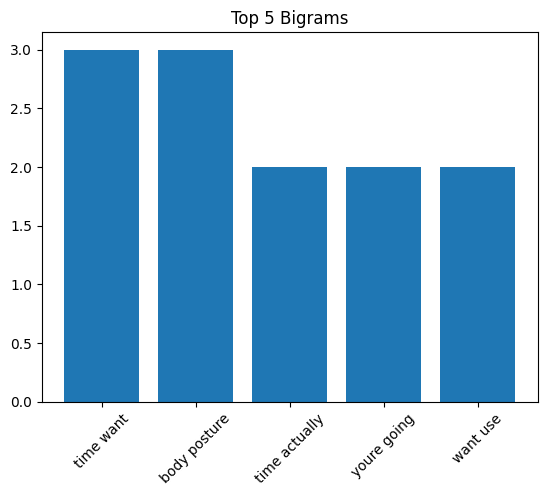

In [ ]:
common_bigrams = bigrams_count.most_common(5)
bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.bar(bg_labels, bg_counts)
plt.title('Top 5 Bigrams')
plt.xticks(rotation=45)
plt.show()

In [ ]:
filtered_bigrams = list(ngrams(filtered_words, 2))
filtered_bigrams_count = Counter(filtered_bigrams)

print(filtered_bigrams_count.most_common(10))

[(('time', 'actually'), 2), (('time', 'use'), 2), (('focus', 'posture'), 2), (('bags', 'hardest'), 2), (('working', 'overtime'), 1), (('overtime', 'brutal'), 1), (('brutal', 'man'), 1), (('man', 'sacrificing'), 1), (('sacrificing', 'pto'), 1), (('pto', 'departments'), 1)]


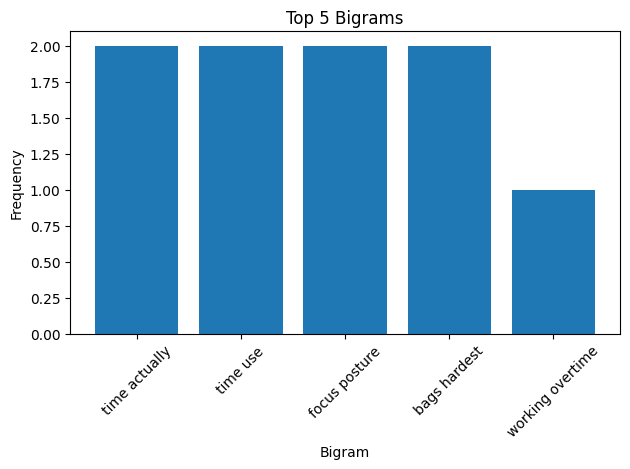

In [ ]:
common_bigrams = filtered_bigrams_count.most_common(5)
bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.bar(bg_labels, bg_counts)
plt.title('Top 5 Bigrams')
plt.xlabel('Bigram')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

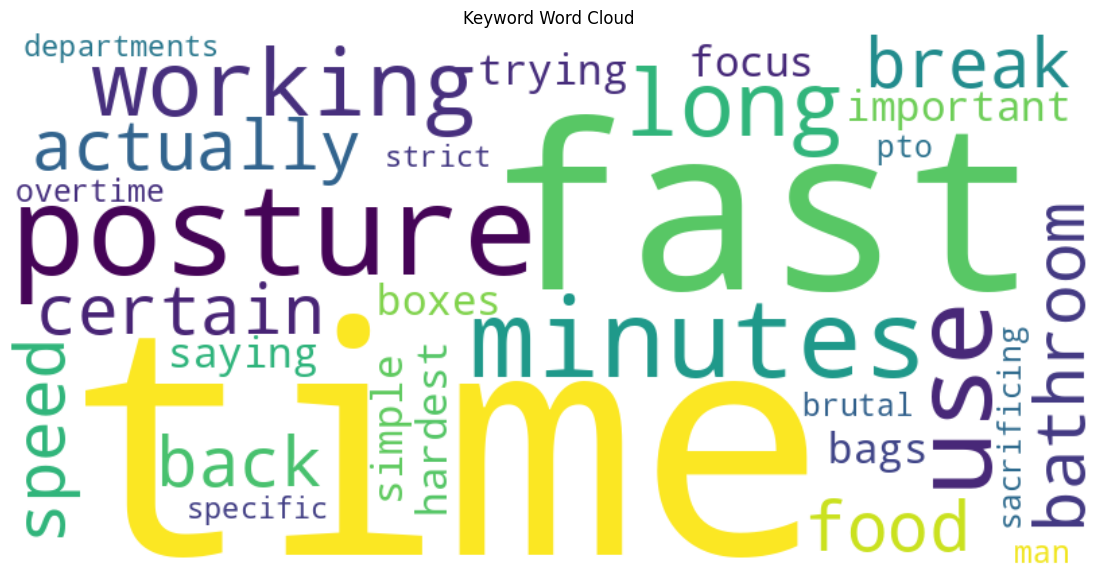

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=30).generate(' '.join(filtered_words))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Keyword Word Cloud")
colormap = 'set4'
plt.show()